In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [20]:
import os

print(os.listdir("/content"))

['.config', 'archive (2).zip', 'data', 'sample_data']


In [21]:
import zipfile
import os

zip_path = "/content/archive (2).zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ ZIP Extracted Successfully!")
print(os.listdir(extract_path))

✅ ZIP Extracted Successfully!
['SouthGermanCredit.asc', 'read_SouthGermanCredit.R', 'codetable.txt']


In [22]:
import pandas as pd

df = pd.read_csv("/content/data/SouthGermanCredit.asc", sep=" ")

print("Dataset Loaded Successfully!")
print(df.shape)
print(df.columns)
df.head()

Dataset Loaded Successfully!
(1000, 21)
Index(['laufkont', 'laufzeit', 'moral', 'verw', 'hoehe', 'sparkont', 'beszeit',
       'rate', 'famges', 'buerge', 'wohnzeit', 'verm', 'alter', 'weitkred',
       'wohn', 'bishkred', 'beruf', 'pers', 'telef', 'gastarb', 'kredit'],
      dtype='object')


,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [23]:
print(df.shape)

(1000, 21)


In [24]:
print(df.columns.tolist())

['laufkont', 'laufzeit', 'moral', 'verw', 'hoehe', 'sparkont', 'beszeit', 'rate', 'famges', 'buerge', 'wohnzeit', 'verm', 'alter', 'weitkred', 'wohn', 'bishkred', 'beruf', 'pers', 'telef', 'gastarb', 'kredit']


In [25]:
df.head()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [26]:
# Check missing values
print(df.isnull().sum())

laufkont    0
laufzeit    0
moral       0
verw        0
hoehe       0
sparkont    0
beszeit     0
rate        0
famges      0
buerge      0
wohnzeit    0
verm        0
alter       0
weitkred    0
wohn        0
bishkred    0
beruf       0
pers        0
telef       0
gastarb     0
kredit      0
dtype: int64


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   laufkont  1000 non-null   int64
 1   laufzeit  1000 non-null   int64
 2   moral     1000 non-null   int64
 3   verw      1000 non-null   int64
 4   hoehe     1000 non-null   int64
 5   sparkont  1000 non-null   int64
 6   beszeit   1000 non-null   int64
 7   rate      1000 non-null   int64
 8   famges    1000 non-null   int64
 9   buerge    1000 non-null   int64
 10  wohnzeit  1000 non-null   int64
 11  verm      1000 non-null   int64
 12  alter     1000 non-null   int64
 13  weitkred  1000 non-null   int64
 14  wohn      1000 non-null   int64
 15  bishkred  1000 non-null   int64
 16  beruf     1000 non-null   int64
 17  pers      1000 non-null   int64
 18  telef     1000 non-null   int64
 19  gastarb   1000 non-null   int64
 20  kredit    1000 non-null   int64
dtypes: int64(21)
memory usage: 164.2 KB


In [28]:
print(df["kredit"].value_counts())

kredit
1    700
0    300
Name: count, dtype: int64


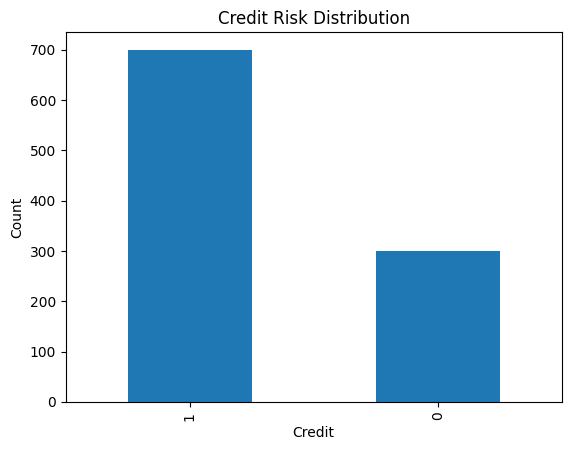

In [29]:
import matplotlib.pyplot as plt

df["kredit"].value_counts().plot(kind="bar")
plt.title("Credit Risk Distribution")
plt.xlabel("Credit")
plt.ylabel("Count")
plt.show()

In [30]:
from sklearn.model_selection import train_test_split

# Features and Target
X = df.drop("kredit", axis=1)
y = df["kredit"]

print(X.shape)
print(y.shape)

(1000, 20)
(1000,)


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 20)
Testing Data: (200, 20)


In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model Trained Successfully!")

✅ Model Trained Successfully!


In [33]:
y_pred = model.predict(X_test)

print("Predictions Completed!")

Predictions Completed!


In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.735


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.42      0.50        62
           1       0.77      0.88      0.82       138

    accuracy                           0.73       200
   macro avg       0.69      0.65      0.66       200
weighted avg       0.72      0.73      0.72       200



In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 26  36]
 [ 17 121]]


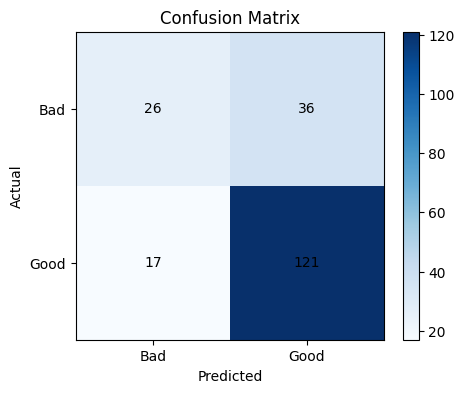

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Bad","Good"])
plt.yticks([0,1], ["Bad","Good"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center", color="black")

plt.show()

     Feature  Importance
4      hoehe    0.138115
0   laufkont    0.106259
1   laufzeit    0.106220
12     alter    0.101204
2      moral    0.063278
3       verw    0.061785
5   sparkont    0.049881
6    beszeit    0.049045
11      verm    0.042358
7       rate    0.041511
8     famges    0.037151
10  wohnzeit    0.036785
16     beruf    0.031521
14      wohn    0.028200
15  bishkred    0.026002
13  weitkred    0.020633
18     telef    0.020624
9     buerge    0.019212
17      pers    0.015530
19   gastarb    0.004688


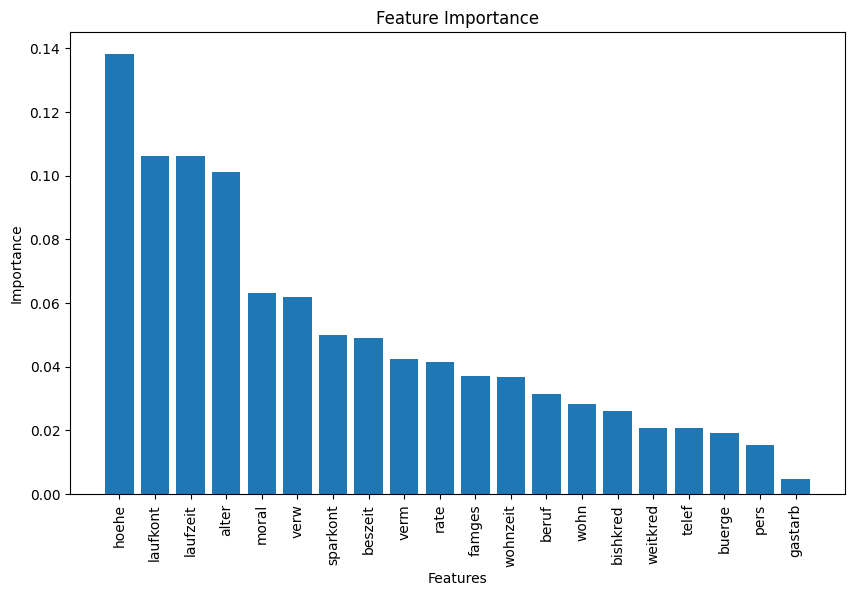

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [39]:
import joblib

joblib.dump(model, "credit_scoring_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [40]:
from google.colab import files

files.download("credit_scoring_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>